In [41]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

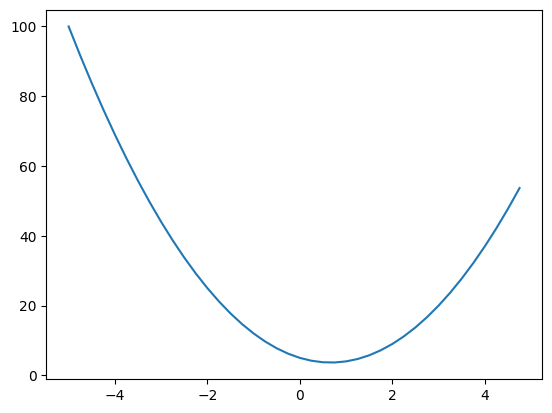

In [16]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)


In [20]:
# derivative of a function. dy/dx = 6x-4. at x = 3, its 14
h = 0.00001
x = 3
(f(x+h) - f(x))/h

14.00003000000538

In [ ]:
# lets get more complex

a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

# dervivative wrt a
h = 0.00001
d1 = a * b + c
a += h
d2 = a * b + c
print((d2-d1)/h)


4.0
-3.000000000064062


## Visualize

In [42]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    dot = Digraph(format="svg", graph_attr={'rankdir': "LR"}) 

    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data , n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

### 01. Class Value

In [ ]:
class Value:
    def __init__(self,data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label


    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data , (self , other), '+')
        
        def _backward():
            self.grad += out.grad * 1
            other.grad += out.grad * 1
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data , (self , other), '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        
        out._backward = _backward
    
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __radd__(self,other):
        return self + other
    

    def __pow__(self,other):

        assert isinstance(other,(int,float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += out.grad * other * self.data ** (other-1)

        out._backward = _backward

        return out

    def __truediv__(self,other):
        return self * other ** -1
    

    def __neg__(self):
        return Value(self.data * -1)
    
    def __sub__(self, other):
        return self  + (-other)
    
    def __rsub__(self,other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += out.grad * (1-t**2)
        
        out._backward = _backward

        return out
    

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.grad * out.data

        out._backward = _backward

        return out



    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child) 
                topo.append(v)

        build_topo(self)

        self.grad = 1
        for node in reversed(topo):
            node._backward()
        


In [70]:
a= Value(2)
b = Value(4)
a-b

Value(data = -2)

In [65]:
math.exp(1)

2.718281828459045

In [76]:
# 2 inputs
x1 = Value(data = 2,label = "x1")
x2 = Value(data = 0,label = "x2")

# weights
w1 = Value(data= -3,label = "w1")
w2 = Value(data= 1,label = "w2")

# bias
b = Value(data = 6.8813735870195432, label = "b")

x1w1 = x1 * w1 ; x1w1.label = "x1w1"
x2w2 = x2w2 = x2 * w2 ; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b ; n.label = "n"

o = n.tanh() ; o.label = "o"  #havent implemented this yet (just the mult and add)


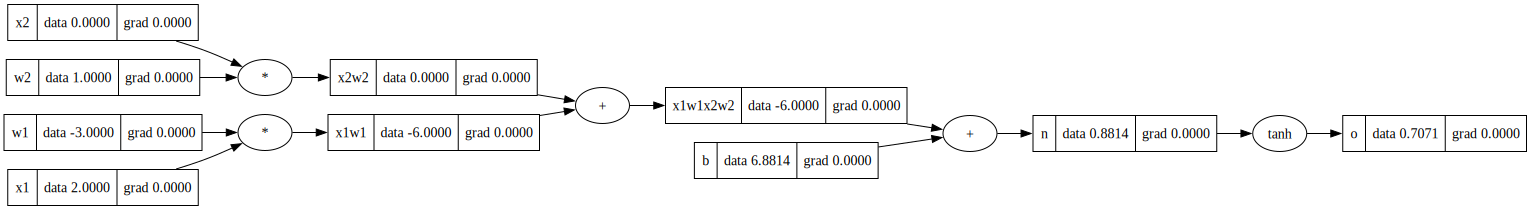

In [77]:
draw_dot(o)

In [78]:
# 2 inputs
x1 = Value(data = 2,label = "x1")
x2 = Value(data = 0,label = "x2")

# weights
w1 = Value(data= -3,label = "w1")
w2 = Value(data= 1,label = "w2")

# bias
b = Value(data = 6.8813735870195432, label = "b")

x1w1 = x1 * w1 ; x1w1.label = "x1w1"
x2w2 = x2w2 = x2 * w2 ; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b ; n.label = "n"

# o = n.tanh() 
o = ((2*n).exp() - 1 )/ ((2*n).exp() + 1 )

o.label = "o"  #havent implemented this yet (just the mult and add)


In [49]:
o.backward()

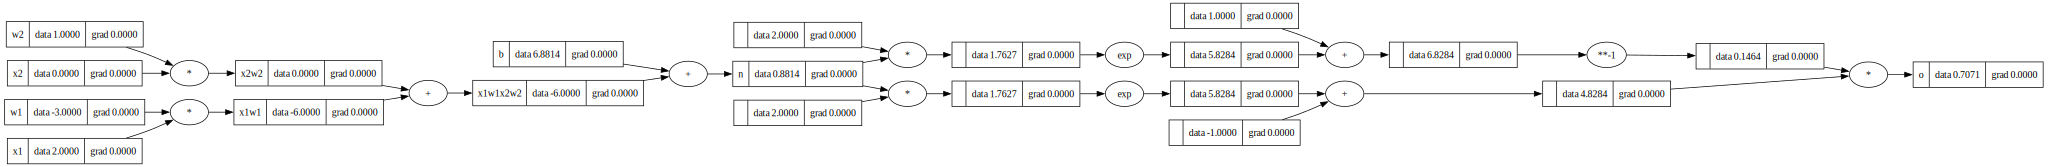

In [79]:
draw_dot(o)

In [80]:
o.backward()

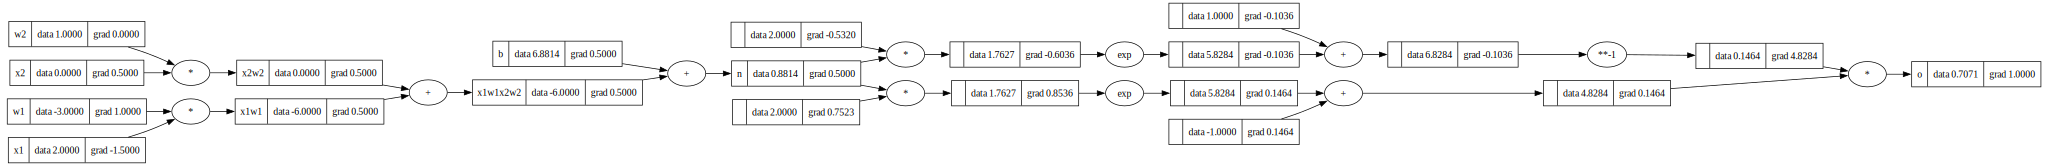

In [81]:
draw_dot(o)

In [62]:
a= Value(2.0)
2*a

Value(data = 4.0)

## Pytorch

In [44]:
# 2 inputs
x1 = Value(data = 2,label = "x1")
x2 = Value(data = 0,label = "x2")

# weights
w1 = Value(data= -3,label = "w1")
w2 = Value(data= 1,label = "w2")

# bias
b = Value(data = 6.8813735870195432, label = "b")

x1w1 = x1 * w1 ; x1w1.label = "x1w1"
x2w2 = x2w2 = x2 * w2 ; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b ; n.label = "n"

# o = n.tanh() 
o = ((2*n).exp() - 1 )/ ((2*n).exp() + 1 )

o.label = "o"  #havent implemented this yet (just the mult and add)


In [45]:
import torch

In [46]:
x1 = torch.tensor([2]).double() ; x1.requires_grad = True
x2 = torch.tensor([0]).double() ; x2.requires_grad = True

w1 = torch.tensor([-3]).double() ; w1.requires_grad = True
w2 = torch.tensor([1]).double() ; w2.requires_grad = True

b = torch.tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b

o = torch.tanh(n)

print(o)

o.backward()

print(x1.grad.item())
print(x2.grad.item())
print(w1.grad.item())
print(w2.grad.item())

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
-1.5000003851533106
0.5000001283844369
1.0000002567688737
0.0


## building simple NN (similar to how pytorch API does)

In [267]:
class Neuron:
    def __init__(self, nin: int):
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)

    def __call__(self, x):
        act = sum([ xi*bi for xi,bi in zip(x,self.w)],self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return [self.b] + self.w


class Layer:
    def __init__(self,nin : int , nout: int):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        param_list = []
        for neuron in self.neurons:
            param_list.extend(neuron.parameters())
        return param_list

class MLP:
    def __init__(self, nin: int, nouts: list[int]):
        self.sz = [nin] + nouts
        self.layers = [Layer(self.sz[i], self.sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        param_list = []
        for layer in self.layers:
            param_list.extend(layer.parameters())
        return param_list


        

In [268]:
x = [2,3,-1]
n = MLP(3,[4,4,1])
n(x)

Value(data = 0.21841746897411302)

In [265]:
len(n.parameters())

41

In [270]:
xs = [[2,3,-1],
      [3,-1,.5],
      [.5,1,1],
      [1,1,-1]]

ys = [1,-1,-1,1]

ypred = [n(x) for x in xs]
print(ypred)

loss = sum([(a - b)**2 for a,b in zip(ys,ypred)])/len(ys)
print(f'loss  :    {loss}')

[Value(data = 0.21841746897411302), Value(data = -0.7585515156615799), Value(data = 0.5630276935402431), Value(data = -0.156545450367974)]
loss  :    Value(data = 1.1124553932336858)


In [190]:
loss.backward()

In [191]:
params = n.get_params()
for p in params:
    p.data -= 0.01 * p.grad

In [274]:
epoch = 20
lr = 0.05

for ep in range(20):

    # forward pass
    ypred = [n(x) for x in xs]

    # calculate loss
    loss = sum([(a - b)**2 for a,b in zip(ys,ypred)])/len(ys)

    print(f'loss at epoch {ep} : {loss.data}')

    # backward pass
    loss.backward()

    params = n.parameters()
    for p in params:
        p.data -= lr * p.grad
        p.grad = 0

        


    

loss at epoch 0 : 0.10108096114867073
loss at epoch 1 : 0.09377871418902906
loss at epoch 2 : 0.0873016678986154
loss at epoch 3 : 0.08153286746128005
loss at epoch 4 : 0.07637402142177051
loss at epoch 5 : 0.07174243590197103
loss at epoch 6 : 0.06756839805184763
loss at epoch 7 : 0.06379297894693069
loss at epoch 8 : 0.06036620744604959
loss at epoch 9 : 0.057245561589384666
loss at epoch 10 : 0.05439472632349791
loss at epoch 11 : 0.05178257175506733
loss at epoch 12 : 0.04938231257802357
loss at epoch 13 : 0.0471708156691325
loss at epoch 14 : 0.0451280285923162
loss at epoch 15 : 0.04323650671115088
loss at epoch 16 : 0.04148102077066457
loss at epoch 17 : 0.03984823024108169
loss at epoch 18 : 0.03832641051433989
loss at epoch 19 : 0.03690522431024276


In [273]:
ypred

[Value(data = 0.7316597982790102),
 Value(data = -0.8316959826504162),
 Value(data = -0.5288167594469386),
 Value(data = 0.6608189808540604)]

In [202]:
ys

[1, -1, -1, 1]

SyntaxError: did you forget parentheses around the comprehension target? (489157646.py, line 3)

## practice

In [160]:
a = Value(2.0 , label = "a")
b = Value(-3.0, label = "b")
c = Value(10.0, label = "c")
e = a*b ; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0,label = "f")
L = d * f ; L.label = "L"

L.grad = 1

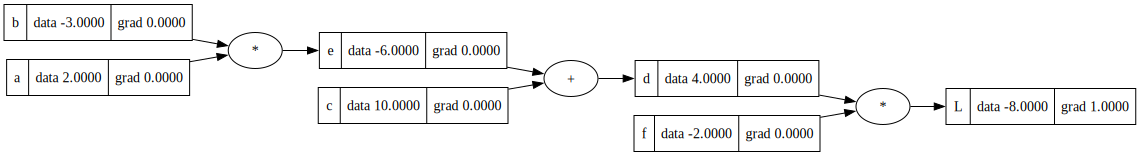

In [161]:
draw_dot(L)

### 03. Manual gradient calculation

In [153]:
def lol():

    h = 0.0001

    a = Value(2.0 , label = "a")
    b = Value(-3.0, label = "b")
    c = Value(10.0, label = "c")
    e = a*b ; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0,label = "f")
    L = d * f ; L.label = "L"
    L1 = L.data

    a = Value(2.0 + h , label = "a")
    b = Value(-3.0, label = "b")
    c = Value(10.0, label = "c")
    e = a*b ; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0,label = "f")
    L = d * f ; L.label = "L"
    L2 = L.data

    print((L2-L1)/ h)

lol()

6.000000000021544


### 04. Activation function

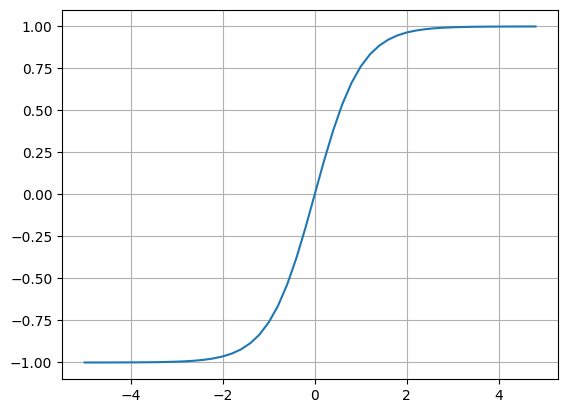

In [166]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))) ; plt.grid();

In [37]:
# 2 inputs
x1 = Value(data = 2,label = "x1")
x2 = Value(data = 0,label = "x2")

# weights
w1 = Value(data= -3,label = "w1")
w2 = Value(data= 1,label = "w2")

# bias
b = Value(data = 6.8813735870195432, label = "b")

x1w1 = x1 * w1 ; x1w1.label = "x1w1"
x2w2 = x2w2 = x2 * w2 ; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b ; n.label = "n"

o = n.tanh() ; o.label = "o"  #havent implemented this yet (just the mult and add)





In [38]:
o.backward()

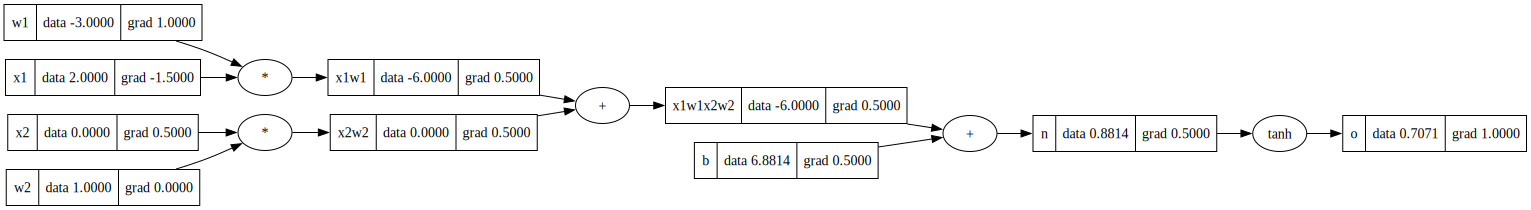

In [39]:
draw_dot(o)

In [ ]:
o.grad = 1

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child) 
        topo.append(v)

build_topo(o)

for node in reversed(topo):
    node._backward()

In [246]:
o._backward()

In [247]:
n._backward()

In [248]:
b._backward()

In [249]:
x1w1x2w2._backward()

In [250]:
x1w1._backward()

In [251]:
x2w2._backward()

### topological graph

In [ ]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child) 
        topo.append(v)

In [264]:
build_topo(o)

outer loop v = o
v = o and child = n
outer loop v = n
v = n and child = x1w1x2w2
outer loop v = x1w1x2w2
v = x1w1x2w2 and child = x2w2
outer loop v = x2w2
v = x2w2 and child = x2
outer loop v = x2
outside the loop
v = x2w2 and child = w2
outer loop v = w2
outside the loop
outside the loop
v = x1w1x2w2 and child = x1w1
outer loop v = x1w1
v = x1w1 and child = w1
outer loop v = w1
outside the loop
v = x1w1 and child = x1
outer loop v = x1
outside the loop
outside the loop
outside the loop
v = n and child = b
outer loop v = b
outside the loop
outside the loop
outside the loop


In [268]:
[x.label for x in topo]

['x2', 'w2', 'x2w2', 'w1', 'x1', 'x1w1', 'x1w1x2w2', 'b', 'n', 'o']

In [269]:
topo

[Value(data = 0),
 Value(data = 1),
 Value(data = 0),
 Value(data = -3),
 Value(data = 2),
 Value(data = -6),
 Value(data = -6),
 Value(data = 6.881373587019543),
 Value(data = 0.8813735870195432),
 Value(data = 0.7071067811865476)]

In [24]:
class Value:
    def __init__(self,data, _op = "" , _children = () , label = "" , grad = 0):
        self.data = data
        self._op = _op
        self._prev = set(_children)
        self.label = label
        self.grad = grad
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self,other):
        out = Value(self.data + other.data, _op = "+" , _children = (self, other))
        def _backward():
            self.grad = out.grad * 1
            other.grad = out.grad * 1

        out._backward = _backward
        return out
    
    def __mul__(self,other):
        out = Value(self.data * other.data, _op = "*" , _children = (self,other))
        def _backward():
            self.grad = out.grad * other.data
            other.grad = out.grad * self.data

        out._backward = _backward
        return out

In [26]:
a = Value(2.0 , label = "a")
b = Value(-3.0, label = "b")
c = Value(10.0, label = "c")
e = a*b ; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0,label = "f")
L = d * f ; L.label = "L"

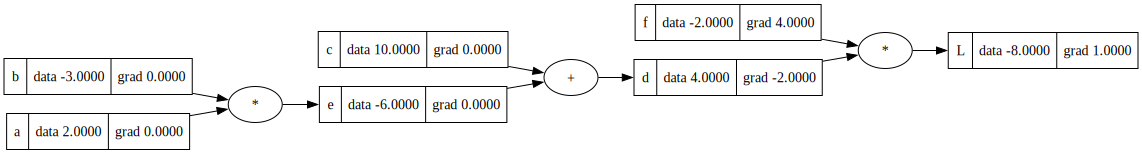

In [30]:
draw_dot(L)

In [ ]:
topo_sort_rev_list = []
def build_topo_sort_reverse(end_node):
    curr_node = end_node
    topo_sort_rev_list.append(end_node)

    if node not in topo_sort_rev_list:
    





In [15]:
xx = list(L._prev)[0]
xx

Value(data = 4.0)

In [28]:
L.grad = 1

In [29]:
L._backward()

In [52]:
f._backward()

In [67]:
d.grad

-2.0

In [1]:
import sys
print(sys.executable)
print("---")

/Users/sanuja/PycharmProjects/Personal/micrograd/.venv/bin/python
---


In [2]:
import micrograd
print(micrograd.__file__)

/Users/sanuja/PycharmProjects/Personal/micrograd/micrograd/__init__.py


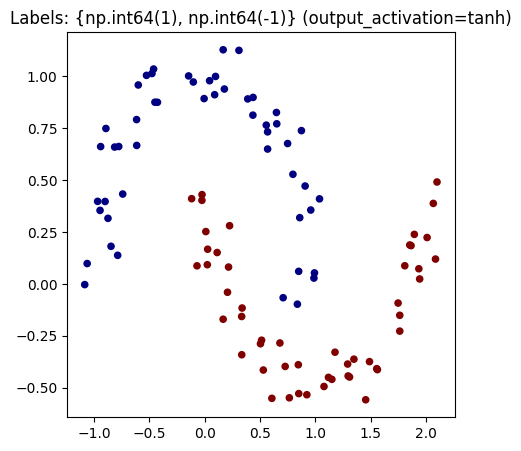

In [ ]:
def get_dataset(n_samples=100, noise=0.1, output_activation='tanh', visualize=True):
    """
    Generate moon dataset with labels compatible with the output activation.
    
    Args:
        n_samples: Number of samples
        noise: Noise level
        output_activation: 'relu' for [0, 1] labels, 'tanh'/'linear' for [-1, 1] labels
        visualize: Whether to plot the dataset
    
    Returns:
        X, y: Features and labels
    """
    from sklearn.datasets import make_moons
    import matplotlib.pyplot as plt
    
    X, y = make_moons(n_samples=n_samples, noise=noise)
    
    # Adjust labels based on output activation
    if output_activation == 'relu':
        # ReLU can only output positive values, use 0 and 1
        y = y  # already 0 or 1 from make_moons
    else:
        # tanh/linear can output negative values, use -1 and 1
        y = y * 2 - 1
    
    # Visualize if requested
    if visualize:
        plt.figure(figsize=(5, 5))
        plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='jet')
        plt.title(f'Labels: {set(y)} (output_activation={output_activation})')
        plt.show()
    
    return X, y

# Example usage
X, y = get_dataset()

In [ ]:
from micrograd.nn import MLP
from micrograd.engine import Value
import numpy as np

nn = MLP(2,[16,16,1],activation=['relu','relu','linear'])
# nn.parameters()

In [3]:
def loss_max_margin(pred: list[Value], labels: list[int]):
    """
    Max-margin loss compatible with both 0/1 and -1/+1 labels.
    
    For -1/+1 labels: maximize margin = prediction * label
    For 0/1 labels: maximize margin for class 1, minimize for class 0
    """
    loss = Value(0)
    
    # Check if labels are 0/1 or -1/+1
    label_set = set(labels)
    is_binary_01 = (0 in label_set or 1 in label_set) and (-1 not in label_set)
    
    for y_i, label_i in zip(pred, labels):
        if is_binary_01:
            # For 0/1 labels with ReLU output
            # Push predictions towards 0 or 1
            if label_i == 1:
                # Want prediction >= 1
                if y_i.data < 1:
                    loss += Value(1) - y_i
            else:  # label_i == 0
                # Want prediction <= 0 (but ReLU outputs >= 0, so push towards 0)
                if y_i.data > 0:
                    loss += y_i
        else:
            # For -1/+1 labels with tanh/linear output
            margin = y_i * label_i
            if margin.data < 1:
                loss += Value(1) - margin
    
    # Calculate accuracy
    if is_binary_01:
        accuracy = [(score_i.data > 0.5) == (label_i == 1) for score_i, label_i in zip(pred, labels)]
    else:
        accuracy = [(score_i.data > 0) == (label_i > 0) for score_i, label_i in zip(pred, labels)]
    
    return loss / len(pred), sum(accuracy) / len(accuracy)


In [ ]:
def train_model(X: list[Value], y:list[int], nn:MLP, epochs: int, lr: float, batch_size : int):

    for ep in range(epochs):

        if batch_size is None:
            Xb, yb = X, y
        else:
            ri = np.random.permutation(X.shape[0])[:batch_size]
            Xb, yb = X[ri], y[ri]

        inputs = [list(map(Value, xrow)) for xrow in Xb]

        # forward pass
        scores = [nn(x) for x in inputs]  # each is Value, not list

        #caluclate loss
        loss ,acc = loss_max_margin(pred = scores, labels = y)

        #backward propapagation
        nn.zero_grad()
        loss.backward()
        lr = 1.0 - 0.9*ep/100
        # update weights
        for p in nn.parameters():
            # print(p.data, p.grad)
            p.data -= lr * p.grad
        
        

        print(f"step {ep} lr {lr} loss {loss.data}, accuracy {acc * 100}%")





In [5]:
train_model(X,y,nn,100,0.05,None)

step 0 loss 1.0621166634947392, accuracy 50.0%
step 1 loss 1.0917495994584554, accuracy 50.0%
step 2 loss 1.3129738723274968, accuracy 50.0%
step 3 loss 0.7480009503036599, accuracy 59.0%
step 4 loss 0.48551071344906727, accuracy 84.0%
step 5 loss 0.5479803185168629, accuracy 75.0%
step 6 loss 0.37758391211753656, accuracy 83.0%
step 7 loss 0.4604343082375408, accuracy 81.0%
step 8 loss 0.32188071451010897, accuracy 83.0%
step 9 loss 0.35588027192955857, accuracy 82.0%
step 10 loss 0.31313764653864423, accuracy 83.0%
step 11 loss 0.3440386121507557, accuracy 82.0%
step 12 loss 0.3001112084210443, accuracy 84.0%
step 13 loss 0.3444237442340106, accuracy 83.0%
step 14 loss 0.287159865104869, accuracy 84.0%
step 15 loss 0.3195108363618865, accuracy 83.0%
step 16 loss 0.269250884433956, accuracy 84.0%
step 17 loss 0.3002415068761975, accuracy 85.0%
step 18 loss 0.2544444208086236, accuracy 84.0%
step 19 loss 0.2963697293032157, accuracy 87.0%
step 20 loss 0.2501500686511416, accuracy 85.0%

In [1]:
from micrograd.train import main

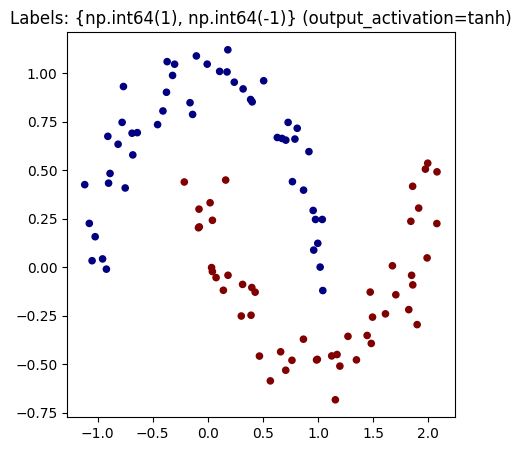

step 0 lr 1.0 loss 0.9328339655990142, accuracy 50.0%
step 1 lr 0.991 loss 0.7401575167299314, accuracy 59.0%
step 2 lr 0.982 loss 0.600053614887211, accuracy 82.0%
step 3 lr 0.973 loss 0.5002366810450027, accuracy 82.0%
step 4 lr 0.964 loss 0.4287246271551509, accuracy 83.0%
step 5 lr 0.955 loss 0.38278699445782144, accuracy 83.0%
step 6 lr 0.946 loss 0.35202135411730245, accuracy 84.0%
step 7 lr 0.937 loss 0.33033851641335044, accuracy 84.0%
step 8 lr 0.9279999999999999 loss 0.3141868451677891, accuracy 85.0%
step 9 lr 0.919 loss 0.30049742911482574, accuracy 85.0%
step 10 lr 0.91 loss 0.28813122913052375, accuracy 88.0%
step 11 lr 0.901 loss 0.2766269812444828, accuracy 88.0%
step 12 lr 0.892 loss 0.26620607485759684, accuracy 88.0%
step 13 lr 0.883 loss 0.2565369213411889, accuracy 89.0%
step 14 lr 0.874 loss 0.24794482086709754, accuracy 90.0%
step 15 lr 0.865 loss 0.24065189076356167, accuracy 90.0%
step 16 lr 0.856 loss 0.2338767706007747, accuracy 90.0%
step 17 lr 0.847 loss 0.

In [2]:
main()

array([-1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,
       -1, -1, -1, -1, -1,  1, -1,  1,  1, -1, -1, -1,  1, -1,  1, -1,  1,
       -1,  1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1,
       -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1, -1, -1,  1,  1, -1,  1,
        1, -1,  1, -1,  1, -1,  1, -1, -1,  1, -1,  1, -1,  1,  1, -1,  1,
       -1, -1, -1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1,  1, -1])

In [6]:
a = Value(2)
b = Value(3)
c = a * b
c.backward()
print(a.grad, b.grad)  # should be 3, 2

3 2
